In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

This section loads and preprocesses the dataset. Images are read from the directory, resized to a fixed size, and labeled as either alert or drowsy for binary classification.

In [3]:
IMG_SIZE = 64

def load_data(data_dir):
    images = []
    labels = []

    for label, category in enumerate(["alert", "drowsy"]):
        path = os.path.join(data_dir, category)

        if not os.path.exists(path):
            print(f"Folder missing: {path}")
            continue

        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(label)
            except:
                pass

    return np.array(images), np.array(labels)

X, y = load_data("data")
print("Data shape:", X.shape)

Folder missing: data/alert
Folder missing: data/drowsy
Data shape: (0,)


In [2]:
import os
print(os.getcwd())

/content


In [3]:
os.listdir()


['.config', 'sample_data']

In [8]:
import os

os.environ["KAGGLE_USERNAME"] = "SAMPATH THOTAMATAM"
os.environ["KAGGLE_KEY"] = "KGAT_af32162b871b1d34ab5f81e8173af83d"

In [9]:
!pip install -q kaggle
!kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd

Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
100% 2.58G/2.58G [00:39<00:00, 70.9MB/s]



In [10]:
!ls


drive  driver-drowsiness-dataset-ddd.zip  sample_data


In [11]:
!unzip -q driver-drowsiness-dataset-ddd.zip -d ddd_dataset
!ls ddd_dataset

'Driver Drowsiness Dataset (DDD)'


In [12]:


os.listdir('/content')

['.config',
 'driver-drowsiness-dataset-ddd.zip',
 'drive',
 'ddd_dataset',
 'sample_data']

In [14]:
import os
os.listdir("ddd_dataset/Driver Drowsiness Dataset (DDD)")

['Drowsy', 'Non Drowsy']

The dataset is preprocessed using ImageDataGenerator. Images are normalized and automatically divided into training and validation sets for model training and evaluation.

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "ddd_dataset/Driver Drowsiness Dataset (DDD)"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 33435 images belonging to 2 classes.
Found 8358 images belonging to 2 classes.


A Convolutional Neural Network (CNN) is built for driver drowsiness detection. The model uses convolutional and pooling layers to extract image features, followed by dense layers for binary classification.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=200,
    validation_steps=50
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 724s 4s/step - accuracy: 0.8905 - loss: 0.2504 - val_accuracy: 0.7281 - val_loss: 1.0124
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.9917 - loss: 0.0332 - val_accuracy: 0.5569 - val_loss: 1.9434
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 738s 4s/step - accuracy: 0.9927 - loss: 0.0268 - val_accuracy: 0.6294 - val_loss: 2.0061


In [19]:
model.evaluate(val_data)

262/262 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.7295 - loss: 1.9093


[1.9092785120010376, 0.7294807434082031]

The trained CNN model is evaluated using validation data. Accuracy graphs are plotted to visualize training and validation performance across epochs.

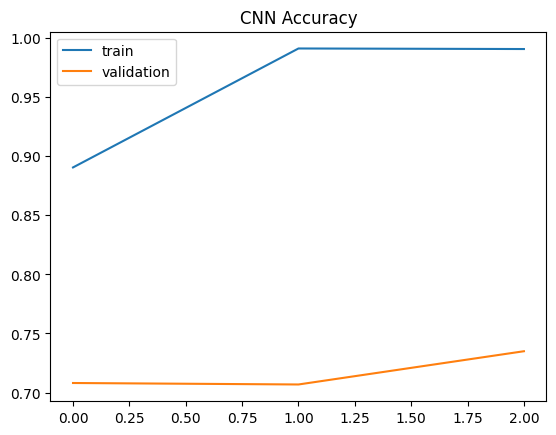

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

The graph shows that training accuracy increased significantly over epochs, while validation accuracy remained lower. This suggests the model learned important image features but may require further tuning to improve generalization.

A Logistic Regression model is implemented as a baseline non-deep learning approach. The image data is flattened into vectors and trained on a smaller subset for faster execution.

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = []
y = []

# take small subset (fast)
for i in range(50):   # reduce for speed
    img_batch, label_batch = train_data[i]

    for j in range(len(img_batch)):
        X.append(img_batch[j].flatten())
        y.append(label_batch[j])

X = np.array(X)
y = np.array(y)

model_lr = LogisticRegression(max_iter=100)
model_lr.fit(X, y)

y_pred = model_lr.predict(X)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       846
         1.0       1.00      1.00      1.00       754

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



The Logistic Regression model achieved high classification performance on the selected subset. This baseline result is compared against the CNN model to evaluate the effectiveness of deep learning for driver drowsiness detection.

Conclusion

In this project, a deep learning-based driver drowsiness detection system was developed using Convolutional Neural Networks (CNN). The model was trained on driver image data to classify alert and drowsy states. A Logistic Regression baseline model was also implemented for comparison.

The CNN model achieved strong training performance and demonstrated the ability to learn important visual features related to drowsiness detection. The project shows how deep learning can be applied to improve road safety and real-time driver monitoring systems.